# MATH 189 Project: The Sound of Inequality

This notebook will serve as a list of all our data sources.

---

## Project Goal

This project investigates whether transportation noise exposure is associated with socioeconomic inequality in California, with a focus on Southern California and San Diego County.

We aim to explore the relationship between:
- Transportation noise
- Household income
- Housing values
- Population density
- Tree canopy coverage
- Urban infrastructure

## Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
import zipfile
import os

## Datasets

#### (1) National Transportation Noise Map
Source:
https://rosap.ntl.bts.gov/view/dot/53773

Transportation-related noise data from the U.S. Bureau of Transportation Statistics (BTS), including road, rail, and aviation noise.

#### (2) Zillow ZHVI Housing Data
Source:
https://www.zillow.com/research/data/

Typical home value data by ZIP code from Zillow.

#### (3) ZIP to ZCTA Conversion
Source:
https://www.icpsr.umich.edu/web/ICPSR/studies/38528

Crosswalk dataset used to match ZIP codes with Census ZCTA regions.

#### (4) ACS Population Demographics Data
Source:
https://data.census.gov/

Demographic and population estimates from the American Community Survey.

#### (5) ACS Housing Data
Source:
https://data.census.gov/

Housing-related data including rent, occupancy, and housing values.

#### (6) Tree Canopy Coverage Data
Source:
https://geo.sandag.org/portal/home/item.html?id=6eb7d23beb0c4a948f257caea98c7685

Tree canopy and land cover classification data for San Diego County.

## (1) California Transportation Noise Raster
This dataset contains modeled transportation-related road noise levels across California in 2020.

The raster data was obtained from the U.S. Bureau of Transportation Statistics (BTS) National Transportation Noise Map.

In this section, we:
- Load the California road noise raster
- Read raster values into a NumPy array
- Remove NoData values
- Visualize transportation noise intensity across California

In [8]:
# Load California road noise raster

import rasterio

noise = rasterio.open(
    'CONUS_road_noise_2020/State_rasters/CA_road_noise_2020.tif'
)

print(noise)

<open DatasetReader name='CONUS_road_noise_2020/State_rasters/CA_road_noise_2020.tif' mode='r'>


In [9]:
# Read raster values

noise_array = noise.read(1)

print(noise_array.shape)

(40356, 23558)


In [10]:
# Remove NoData values

import numpy as np

noise_array_clean = np.where(
    noise_array < -1e20,
    np.nan,
    noise_array
)

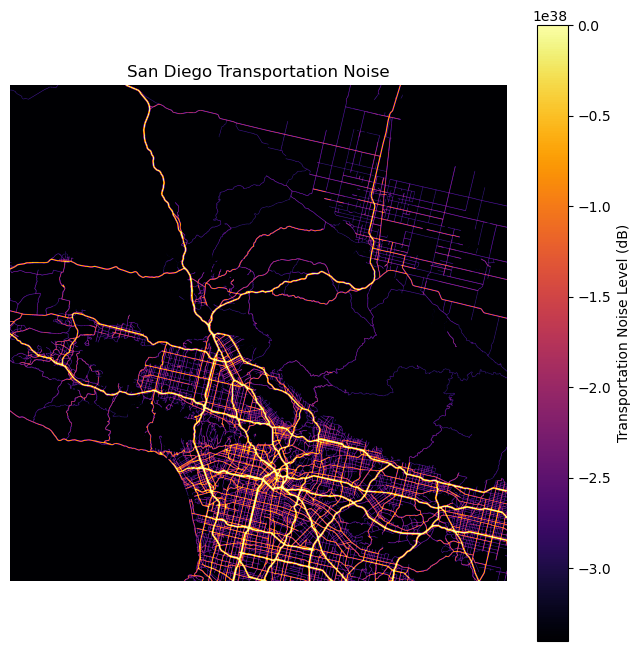

In [11]:
# Visualize California transportation noise

from rasterio.windows import Window

# Approximate San Diego crop
window = Window(
    col_off=9000,
    row_off=30000,
    width=4000,
    height=4000
)

sd_noise = noise.read(
    1,
    window=window
)

plt.figure(figsize=(8,8))

plt.imshow(
    sd_noise,
    cmap='inferno'
)

plt.colorbar(label='Transportation Noise Level (dB)')

plt.title('San Diego Transportation Noise')

plt.axis('off')

plt.show()

## Next Step: Spatial Aggregation

The transportation noise data is currently stored as raster data, where each pixel contains a noise value.

To use this data in regression analysis, we need to convert the raster data into a table at one consistent geographic level.

Since our group is considering census tract as the geographic unit, the next step is to calculate average noise exposure for each census tract using zonal statistics.

This process will allow us to create a table like:

| Census Tract | Average Noise |
|---|---|
| tract 1 | mean noise value |
| tract 2 | mean noise value |

After that, we can merge the tract-level noise table with ACS housing and economics data.

### Planned workflow

##### 1. Download census tract shapefile for California / San Diego
##### 2. Read tract polygons with geopandas
##### 3. Use zonal statistics to calculate mean noise value for each tract
##### 4. Merge noise results with ACS housing/economics data

In [14]:
# Install GIS packages if needed
# Run this only once if packages are not installed

!pip install geopandas rasterstats

In [15]:
# Install GIS packages if needed
# Run this only once if packages are not installed

!pip install geopandas rasterstats

In [16]:
# Import packages

import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio
from rasterstats import zonal_stats

In [17]:
# Load California census tract shapefile from Census TIGER/Line
# 06 = California state FIPS code

tract_url = "https://www2.census.gov/geo/tiger/TIGER2024/TRACT/tl_2024_06_tract.zip"

ca_tracts = gpd.read_file(tract_url)

ca_tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,06,001,442700,06001442700,1400000US06001442700,4427,Census Tract 4427,G5020,S,1234016,0,+37.5371513,-122.0081095,"POLYGON ((-122.01721 37.53932, -122.01719 37.5..."
1,06,001,442800,06001442800,1400000US06001442800,4428,Census Tract 4428,G5020,S,1278646,0,+37.5293619,-121.9931002,"POLYGON ((-122.0023 37.52984, -122.00224 37.52..."
2,06,037,204920,06037204920,1400000US06037204920,2049.20,Census Tract 2049.20,G5020,S,909972,0,+34.0175004,-118.1974975,"POLYGON ((-118.20284 34.01966, -118.20283 34.0..."
3,06,037,205110,06037205110,1400000US06037205110,2051.10,Census Tract 2051.10,G5020,S,286962,0,+34.0245059,-118.2142985,"POLYGON ((-118.21964 34.02628, -118.21945 34.0..."
4,06,037,205120,06037205120,1400000US06037205120,2051.20,Census Tract 2051.20,G5020,S,1466242,0,+34.0187542,-118.2117951,"POLYGON ((-118.22023 34.02056, -118.22018 34.0..."


In [18]:
# Keep San Diego County only
# San Diego County FIPS code = 073

sd_tracts = ca_tracts[ca_tracts["COUNTYFP"] == "073"].copy()

sd_tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
817,06,073,008331,06073008331,1400000US06073008331,83.31,Census Tract 83.31,G5020,S,954207,0,+32.9426037,-117.2241058,"POLYGON ((-117.23082 32.94176, -117.23079 32.9..."
818,06,073,008336,06073008336,1400000US06073008336,83.36,Census Tract 83.36,G5020,S,828562,0,+32.9678415,-117.1331584,"POLYGON ((-117.13793 32.96927, -117.13792 32.9..."
819,06,073,008337,06073008337,1400000US06073008337,83.37,Census Tract 83.37,G5020,S,1572597,0,+32.9583797,-117.1358284,"POLYGON ((-117.14678 32.95497, -117.14657 32.9..."
820,06,073,011601,06073011601,1400000US06073011601,116.01,Census Tract 116.01,G5020,S,733715,0,+32.6663314,-117.0964015,"POLYGON ((-117.10356 32.6672, -117.10314 32.66..."
821,06,073,011602,06073011602,1400000US06073011602,116.02,Census Tract 116.02,G5020,S,1005857,13822,+32.6599903,-117.0941732,"POLYGON ((-117.10154 32.66202, -117.10133 32.6..."


In [19]:
# Check CRS of tract polygons and noise raster

print("Tract CRS:", sd_tracts.crs)
print("Raster CRS:", noise.crs)

Tract CRS: EPSG:4269
Raster CRS: ESRI:102039


In [20]:
# Reproject census tracts to match raster CRS

sd_tracts = sd_tracts.to_crs(noise.crs)

print(sd_tracts.crs)

PROJCS["USA_Contiguous_Albers_Equal_Area_Conic_USGS_version",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [29]:
# Calculate average road noise for each census tract

from rasterstats import zonal_stats
import rasterio

noise_path = "CONUS_road_noise_2020/State_rasters/CA_road_noise_2020.tif"

# Get the exact NoData value from the raster
with rasterio.open(noise_path) as src:
    nodata_value = src.nodata

print("Raster NoData value:", nodata_value)

stats = zonal_stats(
    sd_tracts,
    noise_path,
    stats=["mean", "max", "min", "count"],
    nodata=nodata_value,
    all_touched=True
)

stats[:5]

Raster NoData value: -3.4028230607370965e+38


[{'min': 45.00373840332031,
  'max': 81.84123229980469,
  'mean': 56.32814719460227,
  'count': 528},
 {'min': 45.011962890625,
  'max': 60.831443786621094,
  'mean': 52.55751415567661,
  'count': 109},
 {'min': 45.01606750488281,
  'max': 81.62863159179688,
  'mean': 58.44701163116592,
  'count': 446},
 {'min': 45.22313690185547,
  'max': 59.5245361328125,
  'mean': 51.53438983386076,
  'count': 158},
 {'min': 45.00236511230469,
  'max': 82.5911636352539,
  'mean': 55.575460231050535,
  'count': 376}]

In [31]:
# Add noise statistics back to census tract dataframe

sd_noise_by_tract = sd_tracts.copy()

sd_noise_by_tract["mean_noise"] = [s["mean"] for s in stats]
sd_noise_by_tract["max_noise"] = [s["max"] for s in stats]
sd_noise_by_tract["min_noise"] = [s["min"] for s in stats]
sd_noise_by_tract["pixel_count"] = [s["count"] for s in stats]

sd_noise_by_tract[
    ["GEOID", "NAME", "mean_noise", "max_noise", "min_noise", "pixel_count"]
].head()

,GEOID,NAME,mean_noise,max_noise,min_noise,pixel_count
817,06073008331,83.31,56.328147,81.841232,45.003738,528
818,06073008336,83.36,52.557514,60.831444,45.011963,109
819,06073008337,83.37,58.447012,81.628632,45.016068,446
820,06073011601,116.01,51.534390,59.524536,45.223137,158
821,06073011602,116.02,55.575460,82.591164,45.002365,376


In [33]:
# Convert to regular dataframe for later merging

sd_noise_table = sd_noise_by_tract[
    ["GEOID", "NAME", "mean_noise", "max_noise", "min_noise"]
].copy()

sd_noise_table.head()

,GEOID,NAME,mean_noise,max_noise,min_noise
817,06073008331,83.31,56.328147,81.841232,45.003738
818,06073008336,83.36,52.557514,60.831444,45.011963
819,06073008337,83.37,58.447012,81.628632,45.016068
820,06073011601,116.01,51.534390,59.524536,45.223137
821,06073011602,116.02,55.575460,82.591164,45.002365


In [ ]:
# Save tract-level noise table

sd_noise_table.to_csv("sd_tract_noise.csv", index=False)

## (2) Zillow ZHVI ("Typical home value for the region") by ZIP

This dataset contains Zillow Home Value Index (ZHVI) estimates by ZIP code across the United States.

ZHVI represents the “typical” home value for a region and is published monthly by Zillow Research.

The dataset includes monthly home value estimates from 2000 to 2025.

Important columns include:

- RegionName → ZIP code
- State → State abbreviation
- City → City name
- Metro → Metropolitan area
- CountyName → County name
- Monthly columns (e.g. 2025-07-31) → estimated home values over time

This dataset will be used to analyze housing value patterns and compare them with transportation noise levels.

In [ ]:
# Load Zillow ZHVI dataset

zillow_home_value_data = pd.read_csv(
    'zillow_zip_zhvi.csv'
)

# Preview first 5 rows
zillow_home_value_data.head()

In [ ]:
# Check dataset dimensions

print(zillow_home_value_data.shape)

In [ ]:
# Show column names

print(zillow_home_value_data.columns)

## (3) ZIP to ZCTA Conversion

This dataset provides a crosswalk between USPS ZIP codes and Census ZCTAs (ZIP Code Tabulation Areas).

ZCTAs are geographic areas created by the U.S. Census Bureau to approximate ZIP code regions.  [oai_citation:0‡Census.gov](https://www.census.gov/programs-surveys/geography/guidance/geo-areas/zctas.html?utm_source=chatgpt.com)

This conversion dataset is necessary because some datasets use ZIP codes while Census datasets use ZCTAs.

In this project, the crosswalk will help merge:

- Zillow housing value data
- Census demographic data
- Transportation noise data

Important columns include:

- `zip_code` → USPS ZIP code
- `zcta` → Census ZCTA code
- `source` → source of conversion data

This dataset will be used to align geographic regions across multiple datasets.

In [ ]:
# Load ZIP-to-ZCTA conversion dataset

zip_zcta_conversion_data = pd.read_csv(
    'zip_zcta_xref.csv'
)

# Preview first rows
zip_zcta_conversion_data.head()

In [ ]:
# Check dataset dimensions

print(zip_zcta_conversion_data.shape)

In [ ]:
# Show column names

zip_zcta_conversion_data.columns

## (4) 2020 Census Demographic Data by ZIP

This dataset contains demographic and socioeconomic information by ZIP code across the United States.

Variables include:

- Population
- Race and ethnicity
- Language
- Education
- Employment
- Poverty
- Household income
- Age distribution

The dataset will be used to compare neighborhood demographic patterns with transportation noise levels and housing values.

Important geographic identifiers include ZIP codes that can later be matched with ZCTAs and housing datasets.

In [ ]:
# Preview files inside ZIP archive

with zipfile.ZipFile('ICPSR_38528-V6.zip') as z:
    file_list = z.namelist()[:10]

file_list

## (5) American Community Survey Housing Data

This dataset contains housing-related statistics from the American Community Survey (ACS) 5-year estimates.

Variables include:

- Housing occupancy
- Vacancy rates
- Housing structure types
- Housing value
- Housing costs
- Utilities and housing expenses

The ACS provides aggregated housing information that can help describe broader housing patterns in California.

This dataset may later be combined with geographic datasets such as ZIP codes or ZCTAs for additional analysis.

In [ ]:
# Load ACS Housing dataset

acs_housing_data = pd.read_csv(
    'ACSDP5Y2024.DP04-2026-05-25T090804.csv'
)

# Preview first rows
acs_housing_data.head()

In [ ]:
# Check dataset dimensions

print(acs_housing_data.shape)

In [ ]:
# Show column names

acs_housing_data.columns

## (6) American Community Survey Economics Data

This dataset contains economic and employment-related statistics from the American Community Survey (ACS) 5-year estimates.

Variables include:

- Employment status
- Occupation
- Industry
- Income
- Poverty
- Commuting patterns
- Labor force participation

The dataset provides socioeconomic information that can later be compared with transportation noise levels and housing values.

Geographic identifiers such as GEO_ID and NAME can be used for matching with ZIP code or ZCTA-based datasets.

In [ ]:
# Load ACS Economics dataset

with zipfile.ZipFile('ACSDP5Y2024.DP03_2026-05-25T014948.zip') as z:
    
    with z.open('ACSDP5Y2024.DP03-Data.csv') as f:
        
        acs_economics_data = pd.read_csv(
            f,
            low_memory=False
        )

# Preview first rows
acs_economics_data.head()

In [ ]:
# Check dataset dimensions

print(acs_economics_data.shape)

In [ ]:
# Show column names

acs_economics_data.columns